###AIRO Linear Regression Example
Student Study Hours vs Exam Grade

Created by Caden Wondell

Step 1: Mount to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 2: Import Required Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

Step 3: Load and Preview the Dataset

In [ ]:
data = pd.read_csv(
    "/content/drive/MyDrive/Colab_Notebooks/AIRO_CLUB/Examples/Exam_Score_Prediction.csv"
)
data.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


Step 4: Select the Feature and Target

In [ ]:
# Features: what we give the model
X = data[[
    "study_hours",
    "class_attendance",
    "sleep_hours",
]]

# Target: what we want the model to predict
y = data["exam_score"]

Step 5: Split the Data into Training and Testing Sets

In [ ]:
#Split data into Training and Testing datasets, Training is 80%, Testing is 20%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 6: Create and Train the Linear Regression Model

In [ ]:
model = LinearRegression() #Create the Model

model.fit(X_train, y_train) #Train the model

LinearRegression()

Step 7: Make Predictions

In [ ]:
predictions = model.predict(X_test) #Make predictions

predictions[:5] #Show the first 5 predictions

array([40.27156215, 65.48352593, 56.75529268, 87.60485698, 82.41864565])

Step 8: Compare Predicted and Actual Scores

In [ ]:
results = X_test.copy()
results["Actual Score"] = y_test
results["Predicted Score"] = predictions

results.head(10) #Compare Predictions vs Real scores

,study_hours,class_attendance,sleep_hours,Actual Score,Predicted Score
10650,2.01,48.2,4.9,31.1,40.271562
2041,6.56,45.9,4.4,81.6,65.483526
8668,4.27,41.0,8.9,68.0,56.755293
1114,7.28,91.7,5.9,100.0,87.604857
13902,7.13,64.3,9.5,84.8,82.418646
11963,0.78,45.4,9.1,52.8,38.062718
11072,4.45,54.7,5.2,53.1,57.261269
3002,5.53,69.5,6.0,81.0,69.833331
19771,3.54,62.7,9.2,72.6,60.362890
8115,0.33,48.5,8.9,25.4,36.202687


Step 9: Evaluate the Model

In [ ]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", round(mae, 2)) #The lower the score the better the prediction

Mean Absolute Error: 9.32


Step 10: Visualize the Linear Regression Model

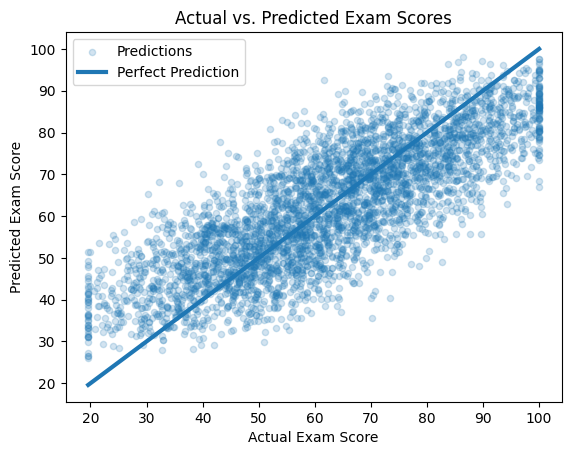

In [ ]:
plt.scatter(
    y_test,
    predictions,
    alpha=0.2,
    s=20,
    label="Predictions"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=3,
    label="Perfect Prediction"
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs. Predicted Exam Scores")
plt.legend()

plt.show()

Step 11: Make a Prediction for a New Student

In [ ]:
new_student = pd.DataFrame({

    "study_hours": [8],

    "class_attendance": [90],

    "sleep_hours": [7],

})

predicted_score = model.predict(new_student)

print("Predicted Exam Score:", round(predicted_score[0], 2))

Predicted Exam Score: 92.81
